# TMDB 5000 Movie Dataset Project by Oh Hui Ting

## Goal
This project explores what factors are associated with movie commercial success and audience ratings.

**Dataset:** TMDB 5000 Movie Dataset

**Kaggle link**: https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata

Main questions:
1. How does movie budget relate to revenue?
2. How are movie ratings distributed?
3. Which genres have the highest average revenue?
4. Are budget, popularity, vote count, and ratings associated with revenue?

## How to use this notebook in Google Colab
1. Download your `kaggle.json` API token from Kaggle.
2. Create a `.env` file locally with this content: `TMDB_API_KEY=YOUR_API_KEY_HERE`.
3. Do **not** upload `.env` or `kaggle.json` to GitHub. Add both to `.gitignore`.
4. Run each cell from top to bottom.
5. Upload `kaggle.json` and `.env` when prompted.

## 1. Install and import libraries

In [60]:
!pip install kaggle python-dotenv -q

import os
import json
import ast
import time
import zipfile
import requests

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from dotenv import load_dotenv
from google.colab import files
from IPython.display import Image, display

sns.set_theme(style="whitegrid")

# Create folders used in this project
os.makedirs("data_raw", exist_ok=True)
os.makedirs("data_cleaned", exist_ok=True)
os.makedirs("exports", exist_ok=True)
os.makedirs("images", exist_ok=True)

## 2. Data pipeline image
This image gives a high-level overview of what happens in the notebook.

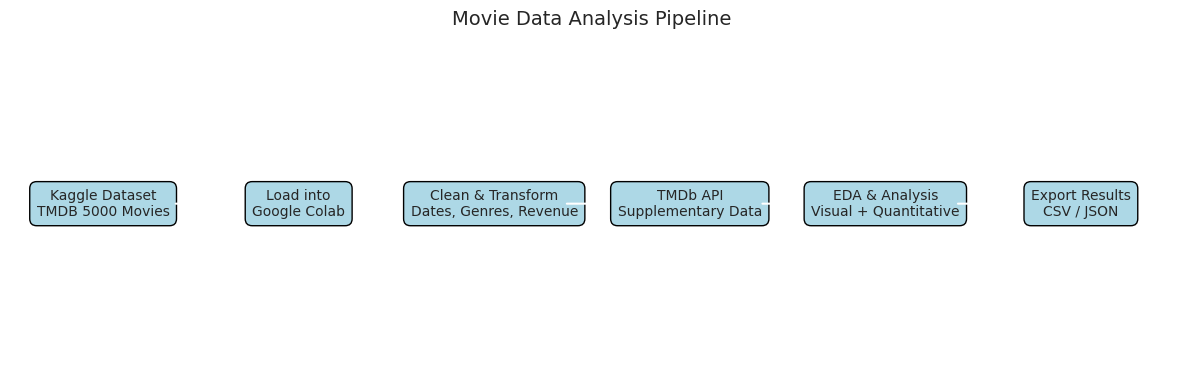

In [61]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.axis("off")

steps = [
    """Kaggle Dataset
TMDB 5000 Movies""",
    """Load into
Google Colab""",
    """Clean & Transform
Dates, Genres, Revenue""",
    """TMDb API
Supplementary Data""",
    """EDA & Analysis
Visual + Quantitative""",
    """Export Results
CSV / JSON"""
]

x_positions = np.linspace(0.08, 0.92, len(steps))

for i, (x, step) in enumerate(zip(x_positions, steps)):
    ax.text(
        x, 0.5, step,
        ha="center", va="center",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.5", facecolor="lightblue", edgecolor="black")
    )

    if i < len(steps) - 1:
        ax.annotate(
            "",
            xy=(x_positions[i + 1] - 0.06, 0.5),
            xytext=(x + 0.06, 0.5),
            arrowprops=dict(arrowstyle="->", lw=1.5)
        )

plt.title("Movie Data Analysis Pipeline", fontsize=14)
plt.tight_layout()

## 3. Introduction

Movies are both creative products and business investments. Studios often spend large production budgets, but a high budget does not always guarantee strong revenue or audience ratings.

This project uses the TMDB 5000 Movie Dataset to explore the relationship between budget, revenue, popularity, genres, and audience ratings. The main goal is to answer:

**What factors are associated with movie commercial success and audience ratings?**

## 4. Load dataset from Kaggle in Google Colab
Upload your `kaggle.json` file.

In [62]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tmdb/tmdb-movie-metadata")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'tmdb-movie-metadata' dataset.
Path to dataset files: /kaggle/input/tmdb-movie-metadata


In [63]:
# Download the TMDB 5000 Movie Dataset from Kaggle
!kaggle datasets download -d tmdb/tmdb-movie-metadata -p data_raw

# Unzip the downloaded dataset
zip_path = "data_raw/tmdb-movie-metadata.zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("data_raw")

print("Files in data_raw folder:")
print(os.listdir("data_raw"))

Dataset URL: https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata
License(s): other
tmdb-movie-metadata.zip: Skipping, found more recently modified local copy (use --force to force download)
Files in data_raw folder:
['tmdb_5000_movies.csv', 'tmdb-movie-metadata.zip', 'tmdb_5000_credits.csv']


In [64]:
# Load the main movie dataset
movies_raw = pd.read_csv("data_raw/tmdb_5000_movies.csv")

print("Top 5 rows of raw movie data:")
display(movies_raw.head())

print("Shape of raw dataset:")
print(movies_raw.shape)

Top 5 rows of raw movie data:


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


Shape of raw dataset:
(4803, 20)


## 5. Export raw data
This allows the raw dataset to be reused later without downloading it again.

In [65]:
movies_raw.to_csv("exports/raw_tmdb_movies.csv", index=False)
print("Raw data exported to exports/raw_tmdb_movies.csv")

Raw data exported to exports/raw_tmdb_movies.csv


## 6. Clean and transform the data
This section creates new variables such as `profit`, `roi`, `release_year`, and `main_genre`.

In [66]:
movies = movies_raw.copy()

# Convert release date into datetime format
movies["release_date"] = pd.to_datetime(movies["release_date"], errors="coerce")
movies["release_year"] = movies["release_date"].dt.year

# Create financial variables
movies["profit"] = movies["revenue"] - movies["budget"]
movies["roi"] = np.where(
    movies["budget"] > 0,
    movies["profit"] / movies["budget"],
    np.nan
)

# Extract genre names from the JSON-like genre column
def extract_genres(genre_text):
    try:
        genres = ast.literal_eval(genre_text)
        return [genre["name"] for genre in genres]
    except:
        return []

movies["genre_list"] = movies["genres"].apply(extract_genres)
movies["main_genre"] = movies["genre_list"].apply(lambda genres: genres[0] if len(genres) > 0 else np.nan)

selected_columns = [
    "id", "title", "budget", "revenue", "profit", "roi",
    "popularity", "runtime", "vote_average", "vote_count",
    "release_date", "release_year", "original_language", "main_genre"
]

movies_cleaned = movies[selected_columns].copy()
movies_cleaned = movies_cleaned.dropna(subset=["title", "release_year"])

# Financial subset: only movies with positive budget and revenue
movies_financial = movies_cleaned[
    (movies_cleaned["budget"] > 0) &
    (movies_cleaned["revenue"] > 0)
].copy()

print("Top 5 rows of cleaned data:")
display(movies_cleaned.head())

print("Shape of cleaned dataset:")
print(movies_cleaned.shape)

print("Shape of financial analysis dataset:")
print(movies_financial.shape)

Top 5 rows of cleaned data:


,id,title,budget,revenue,profit,roi,popularity,runtime,vote_average,vote_count,release_date,release_year,original_language,main_genre
0,19995,Avatar,237000000,2787965087,2550965087,10.763566,150.437577,162.0,7.2,11800,2009-12-10,2009.0,en,Action
1,285,Pirates of the Caribbean: At World's End,300000000,961000000,661000000,2.203333,139.082615,169.0,6.9,4500,2007-05-19,2007.0,en,Adventure
2,206647,Spectre,245000000,880674609,635674609,2.594590,107.376788,148.0,6.3,4466,2015-10-26,2015.0,en,Action
3,49026,The Dark Knight Rises,250000000,1084939099,834939099,3.339756,112.312950,165.0,7.6,9106,2012-07-16,2012.0,en,Action
4,49529,John Carter,260000000,284139100,24139100,0.092843,43.926995,132.0,6.1,2124,2012-03-07,2012.0,en,Action


Shape of cleaned dataset:
(4802, 14)
Shape of financial analysis dataset:
(3229, 14)


In [67]:
print("Missing values in cleaned data:")
display(movies_cleaned.isnull().sum())

Missing values in cleaned data:


,0
id,0
title,0
budget,0
revenue,0
profit,0
roi,1036
popularity,0
runtime,2
vote_average,0
vote_count,0


## 7. API component: Connect to TMDb API
Upload your `.env` file when prompted. The `.env` file should contain:

`TMDB_API_KEY=YOUR_API_KEY_HERE`

The notebook will use the TMDb API as a supplementary data source for a sample of high-revenue movies.

In [68]:
from dotenv import load_dotenv
import os
load_dotenv()

tmdb_api_key = os.getenv("TMDB_API_KEY")

if tmdb_api_key is None:
    print("TMDB_API_KEY not found. Please check your .env file.")
else:
    print("TMDb API key loaded:", tmdb_api_key[:5] + "...")

TMDb API key loaded: c0bff...


In [69]:
# Select a small sample to avoid unnecessary API requests
api_sample = (
    movies_financial
    .sort_values("revenue", ascending=False)
    .head(20)
    [["id", "title"]]
)

print("Movies selected for API enrichment:")
display(api_sample)

Movies selected for API enrichment:


,id,title
0,19995,Avatar
25,597,Titanic
16,24428,The Avengers
28,135397,Jurassic World
44,168259,Furious 7
7,99861,Avengers: Age of Ultron
124,109445,Frozen
31,68721,Iron Man 3
546,211672,Minions
26,271110,Captain America: Civil War


In [70]:
api_results = []

if tmdb_api_key is not None:
    for _, row in api_sample.iterrows():
        movie_id = row["id"]
        url = f"https://api.themoviedb.org/3/movie/{movie_id}"
        params = {
            "api_key": tmdb_api_key,
            "language": "en-US"
        }

        response = requests.get(url, params=params)

        if response.status_code == 200:
            api_results.append(response.json())
        else:
            print(f"Failed for movie ID {movie_id}: {response.status_code}")

        time.sleep(0.2)

print(f"Number of API records collected: {len(api_results)}")

Number of API records collected: 20


In [71]:
# Export raw API data
with open("exports/raw_tmdb_api_data.json", "w") as f:
    json.dump(api_results, f, indent=2)

print("Raw API data exported to exports/raw_tmdb_api_data.json")

Raw API data exported to exports/raw_tmdb_api_data.json


In [72]:
# Convert API results into a clean DataFrame
api_df = pd.DataFrame([
    {
        "id": item.get("id"),
        "imdb_id": item.get("imdb_id"),
        "title_api": item.get("title"),
        "status": item.get("status"),
        "tagline": item.get("tagline"),
        "api_vote_average": item.get("vote_average"),
        "api_vote_count": item.get("vote_count")
    }
    for item in api_results
])

print("Top 5 rows of API data:")
display(api_df.head())

api_df.to_csv("exports/tmdb_api_data.csv", index=False)

Top 5 rows of API data:


,id,imdb_id,title_api,status,tagline,api_vote_average,api_vote_count
0,19995,tt0499549,Avatar,Released,Enter the world of Pandora.,7.602,33878
1,597,tt0120338,Titanic,Released,Nothing on earth could come between them.,7.900,27077
2,24428,tt0848228,The Avengers,Released,Some assembly required.,8.017,37675
3,135397,tt0369610,Jurassic World,Released,The park is open.,6.700,21513
4,168259,tt2820852,Furious 7,Released,Vengeance hits home.,7.217,11247


## 8. Combine Kaggle dataset with API data

In [73]:
movies_enriched = pd.merge(
    movies_cleaned,
    api_df,
    on="id",
    how="left"
)

print("Top 5 rows of enriched data:")
display(movies_enriched.head())

Top 5 rows of enriched data:


,id,title,budget,revenue,profit,roi,popularity,runtime,vote_average,vote_count,release_date,release_year,original_language,main_genre,imdb_id,title_api,status,tagline,api_vote_average,api_vote_count
0,19995,Avatar,237000000,2787965087,2550965087,10.763566,150.437577,162.0,7.2,11800,2009-12-10,2009.0,en,Action,tt0499549,Avatar,Released,Enter the world of Pandora.,7.602,33878.0
1,285,Pirates of the Caribbean: At World's End,300000000,961000000,661000000,2.203333,139.082615,169.0,6.9,4500,2007-05-19,2007.0,en,Adventure,NaN,NaN,NaN,NaN,NaN,NaN
2,206647,Spectre,245000000,880674609,635674609,2.594590,107.376788,148.0,6.3,4466,2015-10-26,2015.0,en,Action,NaN,NaN,NaN,NaN,NaN,NaN
3,49026,The Dark Knight Rises,250000000,1084939099,834939099,3.339756,112.312950,165.0,7.6,9106,2012-07-16,2012.0,en,Action,tt1345836,The Dark Knight Rises,Released,The legend ends.,7.794,24273.0
4,49529,John Carter,260000000,284139100,24139100,0.092843,43.926995,132.0,6.1,2124,2012-03-07,2012.0,en,Action,NaN,NaN,NaN,NaN,NaN,NaN


## 9. Quantitative analysis

In [74]:
print("Summary statistics for cleaned data:")
display(movies_cleaned.describe())

print("Summary statistics for financial analysis subset:")
display(
    movies_financial[[
        "budget", "revenue", "profit", "roi",
        "popularity", "vote_average", "vote_count", "runtime"
    ]].describe()
)

Summary statistics for cleaned data:


,id,budget,revenue,profit,roi,popularity,runtime,vote_average,vote_count,release_date,release_year
count,4802.000000,4.802000e+03,4.802000e+03,4.802000e+03,3.766000e+03,4802.000000,4800.000000,4802.000000,4802.000000,4802,4802.000000
mean,57098.234902,2.905109e+07,8.227777e+07,5.322668e+07,2.532490e+03,21.496776,106.898125,6.093440,690.361724,2002-12-27 23:45:54.352353280,2002.468763
min,5.000000,0.000000e+00,0.000000e+00,-1.657101e+08,-1.000000e+00,0.000372,0.000000,0.000000,0.000000,1916-09-04 00:00:00,1916.000000
25%,9013.750000,8.000000e+05,0.000000e+00,-7.997688e+05,-5.090214e-01,4.671734,94.000000,5.600000,54.000000,1999-07-14 00:00:00,1999.000000
50%,14626.500000,1.500000e+07,1.917498e+07,2.529443e+06,8.675333e-01,12.924931,103.000000,6.200000,235.500000,2005-10-03 00:00:00,2005.000000
75%,58589.750000,4.000000e+07,9.291920e+07,5.533980e+07,2.941424e+00,28.332017,118.000000,6.800000,737.000000,2011-02-16 00:00:00,2011.000000
max,459488.000000,3.800000e+08,2.787965e+09,2.550965e+09,8.499999e+06,875.581305,338.000000,10.000000,13752.000000,2017-02-03 00:00:00,2017.000000
std,88581.302370,4.072447e+07,1.628697e+08,1.359797e+08,1.394602e+05,31.818451,22.561593,1.191496,1234.674268,NaN,12.414354


Summary statistics for financial analysis subset:


,budget,revenue,profit,roi,popularity,vote_average,vote_count,runtime
count,3.229000e+03,3.229000e+03,3.229000e+03,3.229000e+03,3229.000000,3229.000000,3229.000000,3229.000000
mean,4.065444e+07,1.212430e+08,8.058851e+07,2.953822e+03,29.033689,6.309353,977.287395,110.724373
std,4.439674e+07,1.863029e+08,1.581479e+08,1.506101e+05,36.165730,0.873891,1414.309577,20.965694
min,1.000000e+00,5.000000e+00,-1.657101e+08,-9.999995e-01,0.019984,0.000000,0.000000,41.000000
25%,1.050000e+07,1.700000e+07,2.113940e+05,2.246328e-02,10.446722,5.800000,178.000000,96.000000
50%,2.500000e+07,5.518472e+07,2.616557e+07,1.300366e+00,20.410354,6.300000,471.000000,107.000000
75%,5.500000e+07,1.462920e+08,9.748982e+07,3.420822e+00,37.335721,6.900000,1148.000000,121.000000
max,3.800000e+08,2.787965e+09,2.550965e+09,8.499999e+06,875.581305,8.500000,13752.000000,338.000000


In [75]:
correlation_columns = [
    "budget", "revenue", "profit", "popularity",
    "vote_average", "vote_count", "runtime"
]

correlation_matrix = movies_financial[correlation_columns].corr()

print("Correlation matrix:")
display(correlation_matrix)

Correlation matrix:


,budget,revenue,profit,popularity,vote_average,vote_count,runtime
budget,1.000000,0.705399,0.550252,0.431990,-0.031208,0.540165,0.229490
revenue,0.705399,1.000000,0.980003,0.602246,0.187839,0.756210,0.233074
profit,0.550252,0.980003,1.000000,0.588190,0.230041,0.739198,0.210144
popularity,0.431990,0.602246,0.588190,1.000000,0.286994,0.749088,0.182198
vote_average,-0.031208,0.187839,0.230041,0.286994,1.000000,0.377658,0.378641
vote_count,0.540165,0.756210,0.739198,0.749088,0.377658,1.000000,0.257922
runtime,0.229490,0.233074,0.210144,0.182198,0.378641,0.257922,1.000000


In [76]:
genre_summary = (
    movies_financial
    .groupby("main_genre")
    .agg(
        movie_count=("title", "count"),
        average_budget=("budget", "mean"),
        average_revenue=("revenue", "mean"),
        average_rating=("vote_average", "mean"),
        average_profit=("profit", "mean")
    )
    .sort_values("average_revenue", ascending=False)
    .reset_index()
)

print("Top 10 genres by average revenue:")
display(genre_summary.head(10))

Top 10 genres by average revenue:


,main_genre,movie_count,average_budget,average_revenue,average_rating,average_profit
0,Animation,99,8.268113e+07,2.989416e+08,6.374747,2.162605e+08
1,Adventure,288,7.536576e+07,2.460844e+08,6.389583,1.707187e+08
2,Family,38,6.185526e+07,2.340616e+08,6.139474,1.722063e+08
3,Science Fiction,79,5.862414e+07,2.047634e+08,6.339241,1.461393e+08
4,Fantasy,93,6.376816e+07,1.834107e+08,6.247312,1.196426e+08
5,Action,588,5.821985e+07,1.555427e+08,6.069728,9.732282e+07
6,History,18,3.156028e+07,1.007775e+08,6.788889,6.921722e+07
7,Thriller,118,3.816966e+07,9.904276e+07,6.170339,6.087310e+07
8,Romance,70,2.904110e+07,9.892815e+07,6.417143,6.988704e+07
9,Mystery,27,3.250963e+07,9.849483e+07,6.325926,6.598520e+07


## 10. Visual analysis

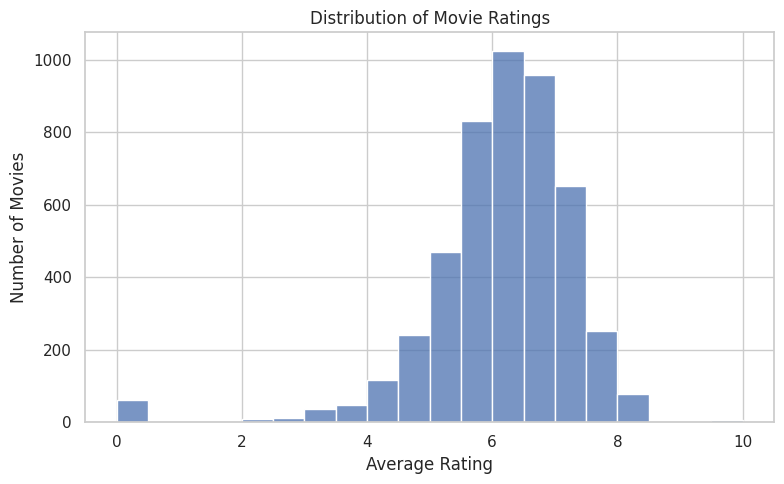

In [77]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=movies_cleaned,
    x="vote_average",
    bins=20
)

plt.title("Distribution of Movie Ratings")
plt.xlabel("Average Rating")
plt.ylabel("Number of Movies")
plt.tight_layout()
plt.show()

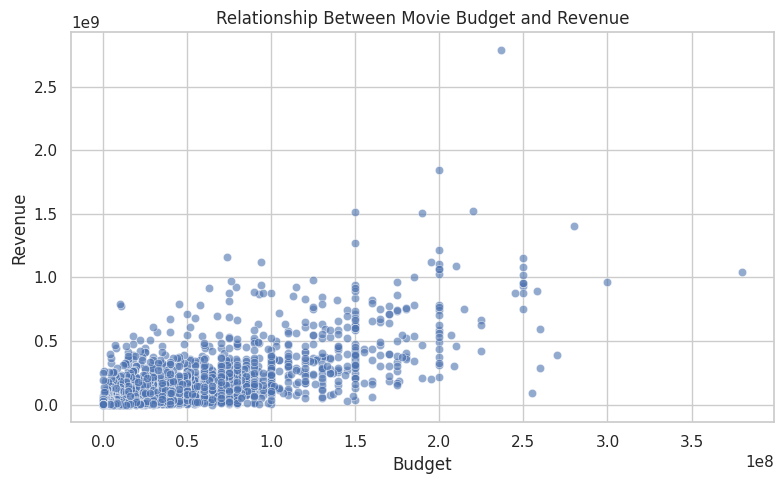

In [78]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=movies_financial,
    x="budget",
    y="revenue",
    alpha=0.6
)

plt.title("Relationship Between Movie Budget and Revenue")
plt.xlabel("Budget")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

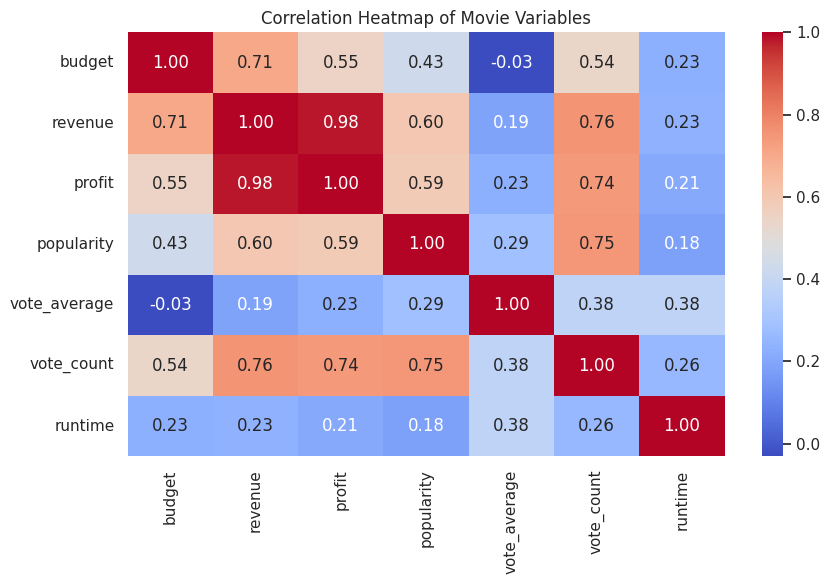

In [79]:
plt.figure(figsize=(9, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Movie Variables")
plt.tight_layout()
plt.show()

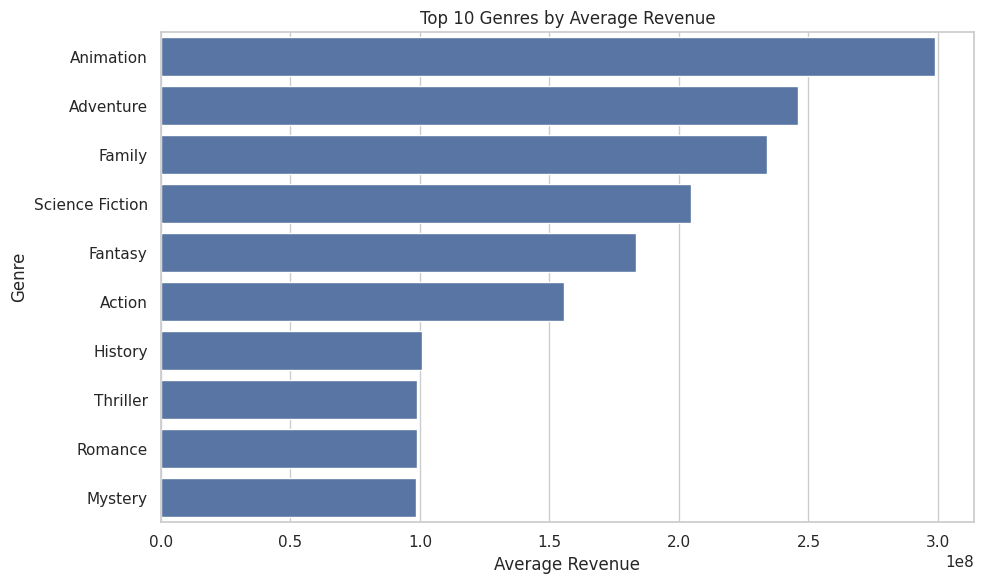

In [80]:
top_genres_by_revenue = genre_summary.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_genres_by_revenue,
    x="average_revenue",
    y="main_genre"
)

plt.title("Top 10 Genres by Average Revenue")
plt.xlabel("Average Revenue")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

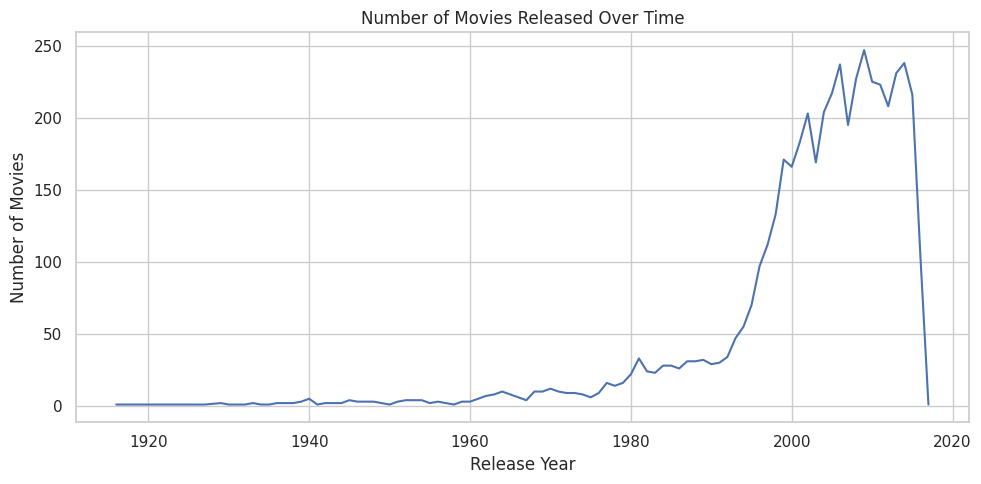

In [81]:
movies_per_year = (
    movies_cleaned
    .dropna(subset=["release_year"])
    .groupby("release_year")["title"]
    .count()
    .reset_index(name="movie_count")
)

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=movies_per_year,
    x="release_year",
    y="movie_count"
)

plt.title("Number of Movies Released Over Time")
plt.xlabel("Release Year")
plt.ylabel("Number of Movies")
plt.tight_layout()
plt.show()

## 11. Optional simple machine learning analysis
This model estimates movie revenue using budget, popularity, vote count, rating, and runtime.

In [82]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

model_data = movies_financial[
    ["budget", "popularity", "vote_count", "vote_average", "runtime", "revenue"]
].dropna()

X = model_data[["budget", "popularity", "vote_count", "vote_average", "runtime"]]
y = model_data["revenue"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

revenue_model = LinearRegression()
revenue_model.fit(X_train, y_train)

y_pred = revenue_model.predict(X_test)

model_results = pd.DataFrame({
    "metric": ["R-squared", "Mean Absolute Error"],
    "value": [r2_score(y_test, y_pred), mean_absolute_error(y_test, y_pred)]
})

print("Model results:")
display(model_results)

Model results:


,metric,value
0,R-squared,6.557836e-01
1,Mean Absolute Error,6.563744e+07


In [83]:
coefficients = pd.DataFrame({
    "feature": X.columns,
    "coefficient": revenue_model.coef_
}).sort_values("coefficient", ascending=False)

print("Regression coefficients:")
display(coefficients)

Regression coefficients:


,feature,coefficient
1,popularity,429236.312176
2,vote_count,59271.239859
0,budget,1.676042
4,runtime,-67840.368230
3,vote_average,-76889.252950


## 12. Export cleaned data and results

In [84]:
movies_cleaned.to_csv("exports/cleaned_tmdb_movies.csv", index=False)
movies_financial.to_csv("exports/financial_tmdb_movies.csv", index=False)
movies_enriched.to_csv("exports/enriched_tmdb_movies.csv", index=False)

genre_summary.to_csv("exports/genre_summary.csv", index=False)
correlation_matrix.to_csv("exports/correlation_matrix.csv")
model_results.to_csv("exports/model_results.csv", index=False)
coefficients.to_csv("exports/regression_coefficients.csv", index=False)

print("All cleaned data and result files exported successfully.")
print("Files in exports folder:")
print(os.listdir("exports"))

All cleaned data and result files exported successfully.
Files in exports folder:
['correlation_matrix.csv', 'raw_tmdb_movies.csv', 'tmdb_api_data.csv', 'financial_tmdb_movies.csv', 'genre_summary.csv', 'enriched_tmdb_movies.csv', 'regression_coefficients.csv', 'raw_tmdb_api_data.json', 'cleaned_tmdb_movies.csv', 'model_results.csv']


## 13. Conclusion

This project explored factors associated with movie commercial success and audience ratings using the TMDB 5000 Movie Dataset.

The analysis shows that budget and revenue are positively related, although the relationship is not perfect. Some high-budget movies generate very high revenue, but others do not perform as strongly. This suggests that budget alone does not guarantee commercial success.

Movie ratings are mostly concentrated around the middle-to-high range, with many movies receiving average ratings between approximately 5 and 7. Very low or very high ratings are less common.

The genre analysis shows that some genres generate higher average revenue than others. This may reflect differences in audience size, production scale, or international appeal.

The correlation analysis and regression model provide a more quantitative view of the relationship between budget, popularity, vote count, ratings, runtime, and revenue. Overall, movie success appears to depend on several factors rather than one single variable.

The TMDb API was used as a supplementary data source to enrich the dataset with additional movie information, demonstrating how an external API can be connected to the notebook.

Possible future improvements include:
- collecting API data for all movies
- analysing cast and director effects
- adjusting older movie revenue and budget for inflation
- building a more advanced predictive model for movie revenue